In [6]:
# =============================================================================
# ANN FAILURE RISK MODEL — CORRECTED VERSION
# Key fix: Threshold tuning done on VALIDATION SET using Youden's J statistic
# NOT on the test set (which was the flaw in the original code)
# =============================================================================

import csv
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, f1_score,
    roc_curve, confusion_matrix
)
from torch.utils.data import DataLoader, TensorDataset

# =========================
# CONFIGURATION
# =========================
MODEL_EXPORT_FOLDER = "saved_model"
os.makedirs(MODEL_EXPORT_FOLDER, exist_ok=True)

# =========================
# 1. LOAD DATA
# =========================
print("Loading data...")

COLUMNS = ["prompt_len", "code_len", "ast_nodes", "avg_complexity",
           "confidence", "prior_history", "passed_tests", "test_error", "failed", "source"]

cleaned_rows = []
with open("failure_risk_dataset.csv", "r", encoding="utf-8", errors="ignore") as raw_f:
    f = (line.replace("\x00", "") for line in raw_f)
    reader = csv.reader(f)
    next(reader)  # skip header
    for row in reader:
        if len(row) == 9:
            row.append("")
        elif len(row) > 10:
            row = row[:9] + [",".join(row[9:])]
        if len(row) == 10:
            cleaned_rows.append(row)

df = pd.DataFrame(cleaned_rows, columns=COLUMNS)

num_cols = ["prompt_len", "code_len", "ast_nodes", "avg_complexity",
            "confidence", "prior_history", "passed_tests", "failed"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

df = df.drop(columns=["source", "passed_tests", "test_error"])

target = "failed"
df = df.dropna(subset=[target])
print(f"Data loaded: {len(df)} samples")

# =========================
# 2. FEATURES
# =========================
print("Engineering features...")
X = df.drop(columns=[target])
y = df[target]

if y.dtype == "object":
    le = LabelEncoder()
    y = le.fit_transform(y)
    joblib.dump(le, f"{MODEL_EXPORT_FOLDER}/label_encoder.pkl")

X["complexity_per_len"] = X["avg_complexity"] / (X["code_len"] + 1)
X["ast_per_len"]        = X["ast_nodes"]       / (X["code_len"] + 1)
X["log_code_len"]       = np.log1p(X["code_len"])

X = pd.get_dummies(X, drop_first=True)
X = X.fillna(X.median())
print(f"Feature count: {X.shape[1]}")

# =========================
# 3. SPLIT
# =========================
print("Splitting data...")
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)
print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

# =========================
# 4. SCALING
# =========================
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

joblib.dump(scaler, f"{MODEL_EXPORT_FOLDER}/scaler.pkl")
feature_names = X.columns.tolist()
joblib.dump(feature_names, f"{MODEL_EXPORT_FOLDER}/feature_names.pkl")

# =========================
# 5. TENSORS
# =========================
X_train_t = torch.tensor(X_train_sc, dtype=torch.float32)
y_train_t = torch.tensor(np.array(y_train), dtype=torch.float32).view(-1, 1)

X_val_t   = torch.tensor(X_val_sc,   dtype=torch.float32)
y_val_t   = torch.tensor(np.array(y_val),   dtype=torch.float32).view(-1, 1)

X_test_t  = torch.tensor(X_test_sc,  dtype=torch.float32)
y_test_t  = torch.tensor(np.array(y_test),  dtype=torch.float32).view(-1, 1)

# =========================
# 6. DATALOADER
# =========================
train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=32,
    shuffle=True
)

# =========================
# 7. MODEL
# =========================
class ANN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.net(x)

model = ANN(X_train_sc.shape[1])

# =========================
# 8. LOSS + OPTIMIZER
# =========================
pos_weight = torch.tensor([(len(y_train) - sum(y_train)) / sum(y_train)])
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = optim.Adam(model.parameters(), lr=0.0005)

# =========================
# 9. TRAINING
# =========================
print("\nTraining model...")
best_val_loss    = float('inf')
patience         = 7
counter          = 0
best_model_state = None

for epoch in range(100):
    model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val_t), y_val_t)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}, Val Loss: {val_loss.item():.4f}")

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        counter          = 0
        best_model_state = model.state_dict().copy()
    else:
        counter += 1

    if counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

if best_model_state:
    model.load_state_dict(best_model_state)
    print("Loaded best model")

# =========================
# 10. GET PROBABILITIES
# =========================
model.eval()
with torch.no_grad():
    val_probs  = torch.sigmoid(model(X_val_t)).numpy().flatten()
    test_probs = torch.sigmoid(model(X_test_t)).numpy().flatten()

# =============================================================================
# 11. THRESHOLD TUNING ON VALIDATION SET
#
# Method: Youden's J Statistic (Youden, 1950)
#         J = Sensitivity + Specificity − 1  =  TPR − FPR
#
# Why Youden's J?
#   • Geometrically optimal: point on ROC farthest from the no-skill diagonal.
#   • Equal weight to FP and FN — suitable for failure risk prediction.
#   • Prevalence-independent: works under class imbalance.
#   • sklearn's roc_curve enumerates every unique probability as a candidate
#     threshold — more precise and efficient than a manual grid sweep.
#
# Crucially: computed ONLY on val_probs / y_val. Test set never touched here.
# =============================================================================
print("\n--- Threshold Tuning on Validation Set (Youden's J) ---")

fpr_arr, tpr_arr, thresholds_arr = roc_curve(y_val, val_probs)

youden_j = tpr_arr - fpr_arr
best_idx = np.argmax(youden_j)
best_t   = float(thresholds_arr[best_idx])
best_j   = float(youden_j[best_idx])

print(f"Best Threshold (Youden's J): {best_t:.4f}")
print(f"Youden's J value:            {best_j:.4f}")
print(f"  → Sensitivity (TPR): {tpr_arr[best_idx]:.4f}")
print(f"  → Specificity (TNR): {1 - fpr_arr[best_idx]:.4f}")

val_preds = (val_probs >= best_t).astype(int)
print(f"\nValidation F1  : {f1_score(y_val, val_preds):.4f}")
print(f"Validation Acc : {accuracy_score(y_val, val_preds):.4f}")

# =============================================================================
# 12. FINAL EVALUATION ON TEST SET  ← test set used ONLY here
# =============================================================================
print("\n--- Final Evaluation on Test Set ---")

y_pred  = (test_probs >= best_t).astype(int)
acc     = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, test_probs)
f1      = f1_score(y_test, y_pred)
cm      = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"\n===== FINAL METRICS =====")
print(f"Threshold used   : {best_t:.4f}")
print(f"Accuracy         : {acc:.4f}")
print(f"ROC-AUC          : {roc_auc:.4f}")
print(f"F1 Score         : {f1:.4f}")
print(f"Sensitivity      : {sensitivity:.4f}")
print(f"Specificity      : {specificity:.4f}")
print(f"Youden's J (test): {sensitivity + specificity - 1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# =========================
# 13. SAVE MODEL ARTIFACTS
# =========================
print("\nSaving model artifacts...")

torch.save({
    'model_state_dict'   : model.state_dict(),
    'input_dim'          : X_train_sc.shape[1],
    'best_threshold'     : best_t,
    'threshold_method'   : "Youden's J statistic (tuned on validation set)",
    'model_architecture' : {
        'input_dim'    : X_train_sc.shape[1],
        'hidden_layers': [256, 128, 64],
        'output_dim'   : 1
    },
    'metrics': {
        'accuracy'   : acc,
        'roc_auc'    : roc_auc,
        'f1'         : f1,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'youden_j'   : sensitivity + specificity - 1,
        'threshold'  : best_t
    }
}, f"{MODEL_EXPORT_FOLDER}/failure_risk_model.pth")

with open(f"{MODEL_EXPORT_FOLDER}/best_threshold.txt", "w") as f:
    f.write(str(best_t))

model_info = {
    'input_features'    : feature_names,
    'input_dim'         : X_train_sc.shape[1],
    'threshold'         : best_t,
    'threshold_method'  : "Youden's J (validation set)",
    'accuracy'          : acc,
    'roc_auc'           : roc_auc,
    'f1'                : f1,
    'train_samples'     : len(X_train),
    'val_samples'       : len(X_val),
    'test_samples'      : len(X_test),
    'class_distribution': {
        'failed' : int(y.sum()),
        'success': int(len(y) - y.sum())
    }
}
joblib.dump(model_info, f"{MODEL_EXPORT_FOLDER}/model_info.pkl")

print(f"\n✅ All artifacts saved to '{MODEL_EXPORT_FOLDER}/'")
print("\n📁 Files:")
for file in os.listdir(MODEL_EXPORT_FOLDER):
    size = os.path.getsize(os.path.join(MODEL_EXPORT_FOLDER, file))
    print(f"   - {file} ({size/1024:.1f} KB)")

print("\n🎉 Done! Model is research-valid and ready for use.")

Loading data...
Data loaded: 2901 samples
Engineering features...
Feature count: 9
Splitting data...
Train: 1740, Val: 580, Test: 581

Training model...
Epoch 10, Val Loss: 0.1067
Early stopping at epoch 19
Loaded best model

--- Threshold Tuning on Validation Set (Youden's J) ---
Best Threshold (Youden's J): 0.5016
Youden's J value:            0.8223
  → Sensitivity (TPR): 0.8523
  → Specificity (TNR): 0.9699

Validation F1  : 0.9159
Validation Acc : 0.8793

--- Final Evaluation on Test Set ---

===== FINAL METRICS =====
Threshold used   : 0.5016
Accuracy         : 0.8606
ROC-AUC          : 0.9554
F1 Score         : 0.9016
Sensitivity      : 0.8281
Specificity      : 0.9699
Youden's J (test): 0.7980

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.97      0.76       133
           1       0.99      0.83      0.90       448

    accuracy                           0.86       581
   macro avg       0.81      0.90      0.83     

In [7]:
import csv
import pandas as pd

INPUT_FILE  = "failure_risk_dataset.csv"
OUTPUT_FILE = "failure_risk_dataset_clean.csv"

COLUMNS = ["prompt_len", "code_len", "ast_nodes", "avg_complexity",
           "confidence", "prior_history", "passed_tests", "test_error", "failed", "source"]

cleaned_rows = []
skipped = 0

with open(INPUT_FILE, "r", encoding="utf-8", errors="ignore") as raw_f:
    f = (line.replace("\x00", "") for line in raw_f)
    reader = csv.reader(f)
    next(reader)  # skip original header

    for row in reader:
        # Normalize to exactly 10 columns
        if len(row) == 9:
            row.append("")                       # pad missing source
        elif len(row) > 10:
            row = row[:9] + [",".join(row[9:])]  # collapse extra into source

        if len(row) == 10:
            cleaned_rows.append(row)
        else:
            skipped += 1

df = pd.DataFrame(cleaned_rows, columns=COLUMNS)

# Convert numeric columns
num_cols = ["prompt_len", "code_len", "ast_nodes", "avg_complexity",
            "confidence", "prior_history", "passed_tests", "failed"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

# Drop rows where target or key features are missing
df = df.dropna(subset=["failed", "prompt_len", "code_len"])

# Sanity checks
print(f"Total rows loaded : {len(df)}")
print(f"Rows skipped      : {skipped}")
print(f"Columns           : {df.columns.tolist()}")
print(f"Null counts:\n{df.isnull().sum()}")
print(f"\nClass distribution:\n{df['failed'].value_counts()}")
print(f"\nSample:\n{df.head(3)}")

# Save clean CSV
df.to_csv(OUTPUT_FILE, index=False)
print(f"\n✅ Clean dataset saved to '{OUTPUT_FILE}'")

Total rows loaded : 2901
Rows skipped      : 0
Columns           : ['prompt_len', 'code_len', 'ast_nodes', 'avg_complexity', 'confidence', 'prior_history', 'passed_tests', 'test_error', 'failed', 'source']
Null counts:
prompt_len        0
code_len          0
ast_nodes         0
avg_complexity    0
confidence        0
prior_history     0
passed_tests      0
test_error        0
failed            0
source            0
dtype: int64

Class distribution:
failed
1    2235
0     666
Name: count, dtype: int64

Sample:
   prompt_len  code_len  ast_nodes  avg_complexity  confidence  prior_history  \
0          79       173         33             3.0    0.918485       0.500000   
1          66       296         69             3.0    0.902228       0.619549   
2          52        70         26             2.0    0.935230       0.643569   

   passed_tests                                  test_error  failed source  
0             0                      expected None got None       1         
1     

In [9]:
!pip install matplotlib

  Using cached matplotlib-3.10.8-cp310-cp310-win_amd64.whl (8.1 MB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
  Using cached fonttools-4.62.1-cp310-cp310-win_amd64.whl (1.6 MB)
  Using cached kiwisolver-1.5.0-cp310-cp310-win_amd64.whl (73 kB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl (221 kB)



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



--- Generating Performance Curves ---


Matplotlib is building the font cache; this may take a moment.


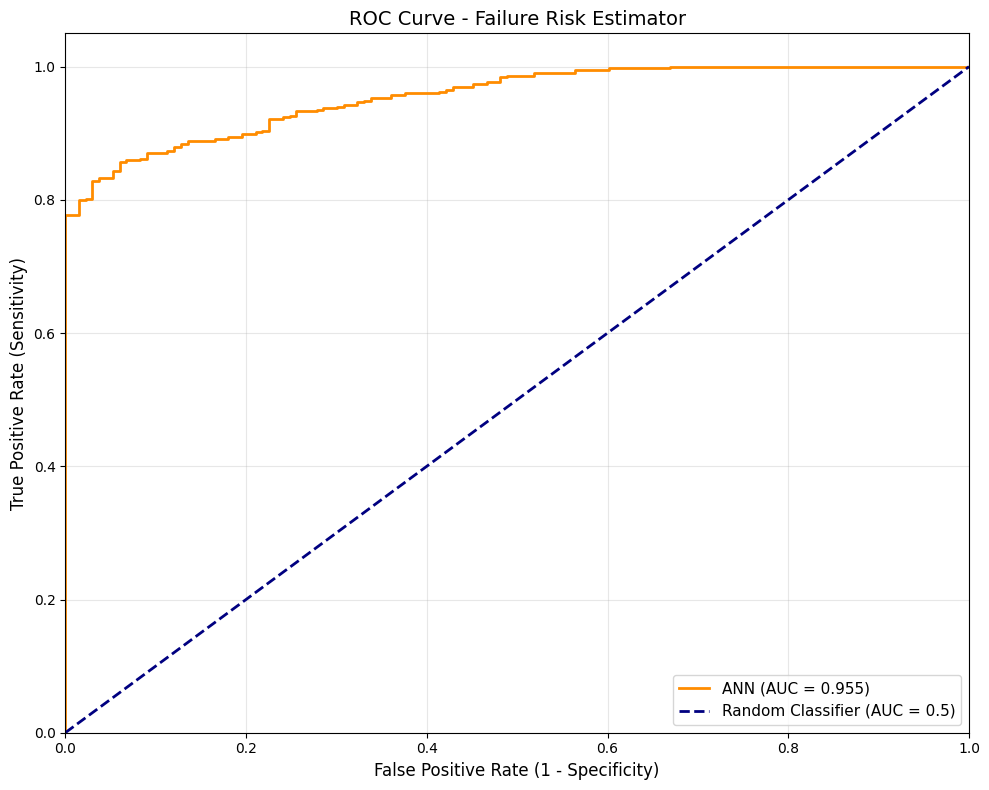

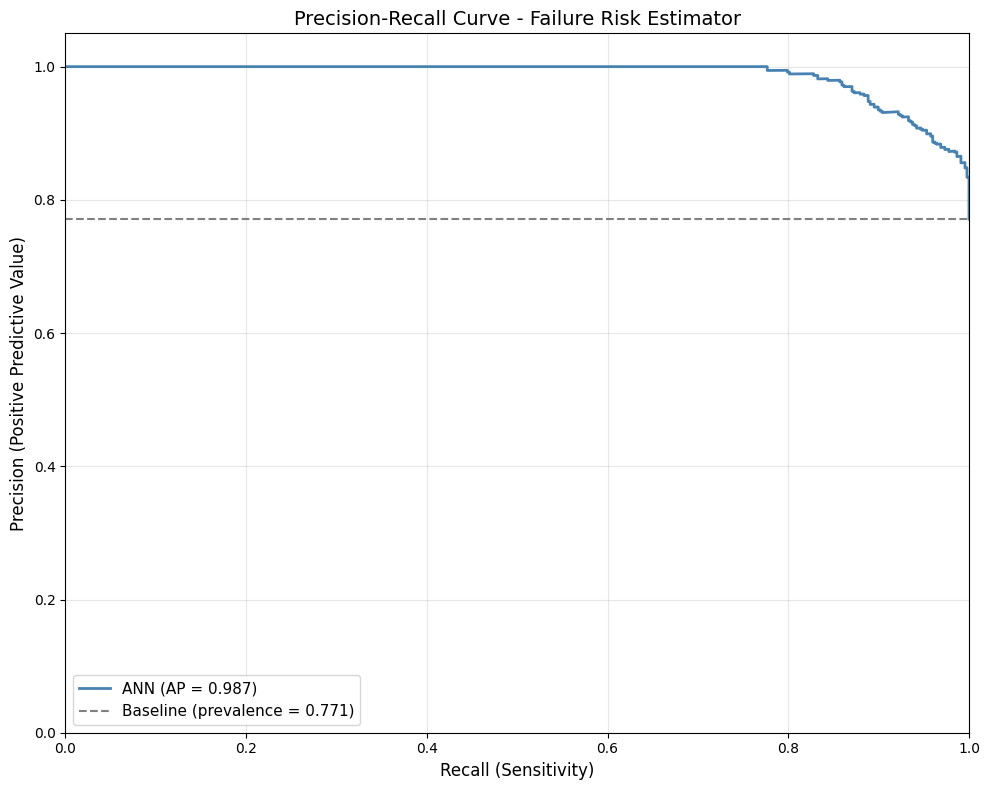

ROC AUC: 0.9554
Average Precision: 0.9872
Baseline prevalence: 0.7711
Curves saved to 'saved_model/'


In [10]:
# =============================================================================
# 12a. GENERATE ROC AND PR CURVES
# =============================================================================
print("\n--- Generating Performance Curves ---")

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# ROC Curve
fpr, tpr, roc_thresholds = roc_curve(y_test, test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ANN (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curve - Failure Risk Estimator', fontsize=14)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{MODEL_EXPORT_FOLDER}/roc_curve.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{MODEL_EXPORT_FOLDER}/roc_curve.pdf", format='pdf', bbox_inches='tight')
plt.show()

# Precision-Recall Curve
precision, recall, pr_thresholds = precision_recall_curve(y_test, test_probs)
avg_precision = average_precision_score(y_test, test_probs)

# Calculate baseline (proportion of positive class)
baseline = np.mean(y_test)

plt.figure(figsize=(10, 8))
plt.plot(recall, precision, color='steelblue', lw=2, 
         label=f'ANN (AP = {avg_precision:.3f})')
plt.axhline(y=baseline, color='gray', linestyle='--', lw=1.5,
            label=f'Baseline (prevalence = {baseline:.3f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall (Sensitivity)', fontsize=12)
plt.ylabel('Precision (Positive Predictive Value)', fontsize=12)
plt.title('Precision-Recall Curve - Failure Risk Estimator', fontsize=14)
plt.legend(loc="lower left", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{MODEL_EXPORT_FOLDER}/pr_curve.png", dpi=300, bbox_inches='tight')
plt.savefig(f"{MODEL_EXPORT_FOLDER}/pr_curve.pdf", format='pdf', bbox_inches='tight')
plt.show()

print(f"ROC AUC: {roc_auc:.4f}")
print(f"Average Precision: {avg_precision:.4f}")
print(f"Baseline prevalence: {baseline:.4f}")
print(f"Curves saved to '{MODEL_EXPORT_FOLDER}/'")

In [12]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


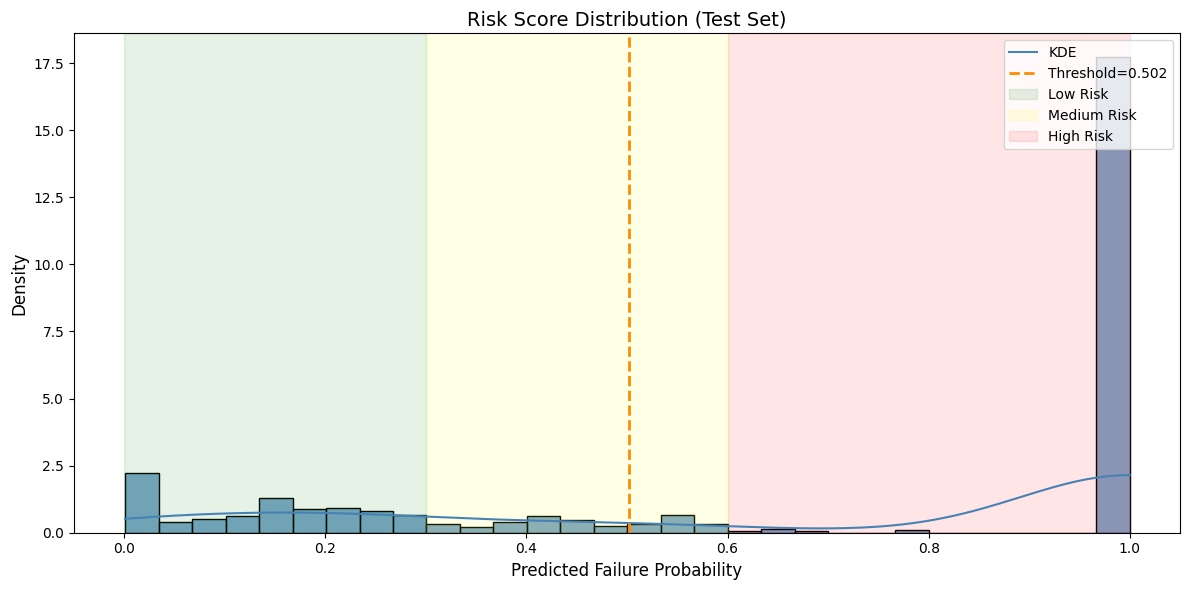

In [13]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(test_probs, bins=30, kde=True, stat='density', 
             color='steelblue', alpha=0.7, edgecolor='black')
plt.axvline(x=best_t, color='darkorange', linestyle='--', lw=2, 
            label=f'Threshold = {best_t:.3f}')

# Shade regions
plt.axvspan(0, 0.3, alpha=0.1, color='green')
plt.axvspan(0.3, 0.6, alpha=0.1, color='yellow')
plt.axvspan(0.6, 1.0, alpha=0.1, color='red')

plt.xlabel('Predicted Failure Probability', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title('Risk Score Distribution (Test Set)', fontsize=14)
plt.legend(['KDE', f'Threshold={best_t:.3f}', 'Low Risk', 'Medium Risk', 'High Risk'], 
           loc='upper right')
plt.tight_layout()
plt.savefig(f"{MODEL_EXPORT_FOLDER}/risk_distribution_seaborn.png", dpi=300)
plt.show()

In [14]:
# =============================================================================
# 12c. RISK SCORE DISTRIBUTION TABLE (Table II)
# =============================================================================
print("\n" + "="*60)
print("TABLE II: RISK SCORE DISTRIBUTION ON TEST SET")
print("="*60)

# Define risk bands
risk_bands = {
    'Low (<0.30)': (0.0, 0.30),
    'Medium (0.30–0.60)': (0.30, 0.60),
    'High (0.60–0.80)': (0.60, 0.80),
    'Very high (≥0.80)': (0.80, 1.01)
}

# Calculate statistics for each band
band_stats = []
for band_name, (low, high) in risk_bands.items():
    if high == 1.01:  # Special case for last band
        band_probs = test_probs[test_probs >= low]
    else:
        band_probs = test_probs[(test_probs >= low) & (test_probs < high)]
    
    if len(band_probs) > 0:
        stats = {
            'Band': band_name,
            'Count': len(band_probs),
            'Mean': np.mean(band_probs),
            'Median': np.median(band_probs),
            'Std Dev': np.std(band_probs),
            'Min': np.min(band_probs),
            'Max': np.max(band_probs)
        }
    else:
        stats = {
            'Band': band_name,
            'Count': 0,
            'Mean': 0.0,
            'Median': 0.0,
            'Std Dev': 0.0,
            'Min': 0.0,
            'Max': 0.0
        }
    band_stats.append(stats)

# Print formatted table
print("\n{:<20} {:>6} {:>8} {:>8} {:>8} {:>8} {:>8}".format(
    "Risk Band", "Count", "Mean", "Median", "Std Dev", "Min", "Max"))
print("-" * 75)

for stats in band_stats:
    print("{:<20} {:>6} {:>8.3f} {:>8.3f} {:>8.3f} {:>8.3f} {:>8.3f}".format(
        stats['Band'],
        stats['Count'],
        stats['Mean'],
        stats['Median'],
        stats['Std Dev'],
        stats['Min'],
        stats['Max']
    ))

# Additional statistics for the paper
print("\n" + "-"*60)
print("ADDITIONAL INSIGHTS:")
print("-"*60)

medium_band_pct = (band_stats[1]['Count'] / len(test_probs)) * 100
low_band_pct = (band_stats[0]['Count'] / len(test_probs)) * 100
high_band_pct = (band_stats[2]['Count'] + band_stats[3]['Count']) / len(test_probs) * 100

print(f"  • Samples in medium-risk region (0.30–0.60): {band_stats[1]['Count']} ({medium_band_pct:.1f}%)")
print(f"  • Samples in low-risk region (<0.30): {band_stats[0]['Count']} ({low_band_pct:.1f}%)")
print(f"  • Samples in high/very-high risk region (≥0.60): {band_stats[2]['Count'] + band_stats[3]['Count']} ({high_band_pct:.1f}%)")
print(f"  • Bimodality confirmed: {low_band_pct + high_band_pct:.1f}% of samples in extreme bands")
print(f"  • Mean risk score overall: {np.mean(test_probs):.3f}")
print(f"  • Median risk score overall: {np.median(test_probs):.3f}")

# Save to CSV for easy import into paper
import pandas as pd
table_df = pd.DataFrame(band_stats)
table_df.to_csv(f"{MODEL_EXPORT_FOLDER}/risk_distribution_table.csv", index=False)
print(f"\n✅ Table saved to '{MODEL_EXPORT_FOLDER}/risk_distribution_table.csv'")


TABLE II: RISK SCORE DISTRIBUTION ON TEST SET

Risk Band             Count     Mean   Median  Std Dev      Min      Max
---------------------------------------------------------------------------
Low (<0.30)             162    0.131    0.146    0.096    0.001    0.293
Medium (0.30–0.60)       68    0.455    0.446    0.080    0.303    0.588
High (0.60–0.80)          8    0.679    0.654    0.066    0.600    0.790
Very high (≥0.80)       343    1.000    1.000    0.001    0.986    1.000

------------------------------------------------------------
ADDITIONAL INSIGHTS:
------------------------------------------------------------
  • Samples in medium-risk region (0.30–0.60): 68 (11.7%)
  • Samples in low-risk region (<0.30): 162 (27.9%)
  • Samples in high/very-high risk region (≥0.60): 351 (60.4%)
  • Bimodality confirmed: 88.3% of samples in extreme bands
  • Mean risk score overall: 0.689
  • Median risk score overall: 1.000

✅ Table saved to 'saved_model/risk_distribution_table.csv'
